# Country Market Analysis using PCA and Clustering

This notebook analyzes country-level economic and governance indicators to identify market segments for strategic decision-making. We use **Principal Component Analysis (PCA)** to reduce dimensionality and **clustering algorithms** (HAC and K-Means) to group similar countries together.


In [55]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## Data Loading and Feature Selection

We load the 2024 data and select 10 key indicators covering:

-   **Economic factors**: GDP per capita, Purchasing power, Imports, Food price inflation
-   **Logistics**: LPI Score (Logistics Performance Index)
-   **Social factors**: Urbanization, Unemployment
-   **Governance**: Political stability, Rule of law, Regulatory quality

Countries with missing values are excluded to ensure a complete dataset for PCA.


In [56]:
df = pd.read_csv("merged_data_cleaned.csv")
df = df[df["Year"] == 2024]
analysis_features = [
    "GDP per capita (current US$)",
    "Purchasing power index",
    "Import",
    "Food Price Inflation (Mean)",
    "LPI Score",
    "Urban population (% of total population)",
    "Unemployment (% of total labor force)",
    "Political Stability and Absence of Violence/Terrorism: Percentile Rank",
    "Rule of Law: Percentile Rank",
    "Regulatory Quality: Percentile Rank",
]
df = df[["Country Name", "Region"] + analysis_features].dropna().reset_index(drop=True)

## Principal Component Analysis (PCA)

PCA transforms our 10 correlated variables into uncorrelated **principal components** that capture the maximum variance in the data. This helps us:

1. **Reduce dimensionality** - Visualize high-dimensional data in 2D/3D
2. **Remove multicollinearity** - Create independent features for clustering
3. **Identify latent factors** - Discover underlying patterns (e.g., "economic development")

### Scree Plot

The scree plot shows how much variance each component explains. We look for the "elbow" where adding more components provides diminishing returns.


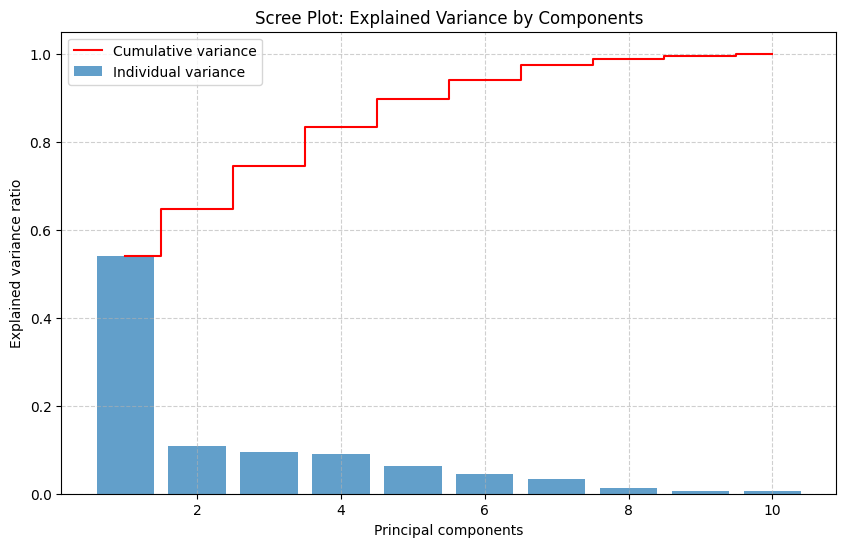

In [57]:
# Standardize the data
x = df[analysis_features].values
x = StandardScaler().fit_transform(x)

# PCA for Scree Plot (All components)
pca_all = PCA(n_components=None)
pca_all.fit(x)
explained_variance = pca_all.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot Scree Plot
plt.figure(figsize=(10, 6))
plt.bar(
    range(1, len(explained_variance) + 1),
    explained_variance,
    alpha=0.7,
    label="Individual variance",
)
plt.step(
    range(1, len(explained_variance) + 1),
    np.cumsum(explained_variance),
    where="mid",
    label="Cumulative variance",
    color="red",
)
plt.ylabel("Explained variance ratio")
plt.xlabel("Principal components")
plt.title("Scree Plot: Explained Variance by Components")
plt.legend(loc="best")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# PCA Projection
pca = PCA(n_components=4)
principalComponents = pca.fit_transform(x)
principalDf = pd.DataFrame(
    data=principalComponents, columns=["PC1", "PC2", "PC3", "PC4"]
)

### Component Loadings

Loadings show the **correlation between original variables and principal components**. High absolute values indicate which variables "drive" each component. This helps us interpret what each PC represents conceptually.


In [58]:
loadings = pd.DataFrame(
    pca.components_.T, columns=["PC1", "PC2", "PC3", "PC4"], index=analysis_features
)

print(loadings)

                                                         PC1       PC2  \
GDP per capita (current US$)                        0.380493  0.055496   
Purchasing power index                              0.397650  0.050977   
Import                                              0.134153 -0.172998   
Food Price Inflation (Mean)                        -0.170817  0.075041   
LPI Score                                           0.375970  0.039040   
Urban population (% of total population)            0.261984  0.527745   
Unemployment (% of total labor force)              -0.110845  0.812872   
Political Stability and Absence of Violence/Ter...  0.324536 -0.123765   
Rule of Law: Percentile Rank                        0.402117 -0.045140   
Regulatory Quality: Percentile Rank                 0.400782 -0.024648   

                                                         PC3       PC4  
GDP per capita (current US$)                        0.087759 -0.166454  
Purchasing power index                 

**Interpretation of Principal Components:**

-   **PC1 = Economic Development & Governance**: High GDP, purchasing power, LPI, and governance scores load together
-   **PC2 = Labor Market Stress & Urbanization**: Driven by unemployment and urban population
-   **PC3 = Trade Exposure & Food Inflation**: Import levels and food price inflation dominate
-   **PC4 = Import-Heavy with Stable Food Prices**: High imports but negative food inflation loading


### Correlation Circles

Correlation circles visualize variable loadings as vectors. Variables pointing in the same direction are positively correlated; opposite directions indicate negative correlation. Vectors near the unit circle are well-represented by those components.


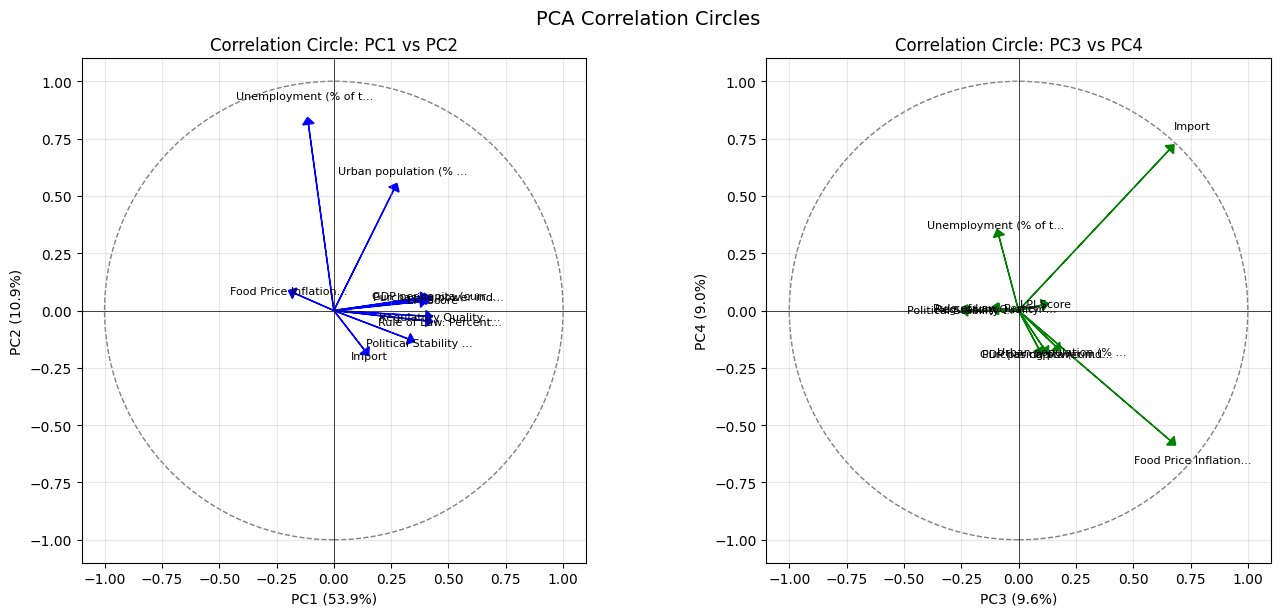

In [59]:
# Correlation Circle (Variables Factor Map)
# Shows how original variables correlate with principal components

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Circle 1: PC1 vs PC2
ax1 = axes[0]
ax1.set_xlim(-1.1, 1.1)
ax1.set_ylim(-1.1, 1.1)

# Draw unit circle
circle1 = plt.Circle((0, 0), 1, color="gray", fill=False, linestyle="--")
ax1.add_patch(circle1)

# Plot arrows for each variable
for i, var in enumerate(analysis_features):
    ax1.arrow(
        0,
        0,
        loadings.iloc[i, 0],
        loadings.iloc[i, 1],
        head_width=0.05,
        head_length=0.03,
        fc="blue",
        ec="blue",
    )
    # Shorten variable names for readability
    short_name = var[:20] + "..." if len(var) > 20 else var
    ax1.text(
        loadings.iloc[i, 0] * 1.15,
        loadings.iloc[i, 1] * 1.15,
        short_name,
        ha="center",
        va="center",
        fontsize=8,
    )

ax1.axhline(y=0, color="k", linestyle="-", linewidth=0.5)
ax1.axvline(x=0, color="k", linestyle="-", linewidth=0.5)
ax1.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax1.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax1.set_title("Correlation Circle: PC1 vs PC2")
ax1.set_aspect("equal")
ax1.grid(True, alpha=0.3)

# Circle 2: PC3 vs PC4
ax2 = axes[1]
ax2.set_xlim(-1.1, 1.1)
ax2.set_ylim(-1.1, 1.1)

circle2 = plt.Circle((0, 0), 1, color="gray", fill=False, linestyle="--")
ax2.add_patch(circle2)

for i, var in enumerate(analysis_features):
    ax2.arrow(
        0,
        0,
        loadings.iloc[i, 2],
        loadings.iloc[i, 3],
        head_width=0.05,
        head_length=0.03,
        fc="green",
        ec="green",
    )
    short_name = var[:20] + "..." if len(var) > 20 else var
    ax2.text(
        loadings.iloc[i, 2] * 1.15,
        loadings.iloc[i, 3] * 1.15,
        short_name,
        ha="center",
        va="center",
        fontsize=8,
    )

ax2.axhline(y=0, color="k", linestyle="-", linewidth=0.5)
ax2.axvline(x=0, color="k", linestyle="-", linewidth=0.5)
ax2.set_xlabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")
ax2.set_ylabel(f"PC4 ({pca.explained_variance_ratio_[3]*100:.1f}%)")
ax2.set_title("Correlation Circle: PC3 vs PC4")
ax2.set_aspect("equal")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle("PCA Correlation Circles", y=1.02, fontsize=14)
plt.show()

### Projection of Individuals

This plot shows each country's position in the PC1-PC2 space. Countries close together have similar profiles. This visualization helps identify outliers and natural groupings before applying clustering algorithms.


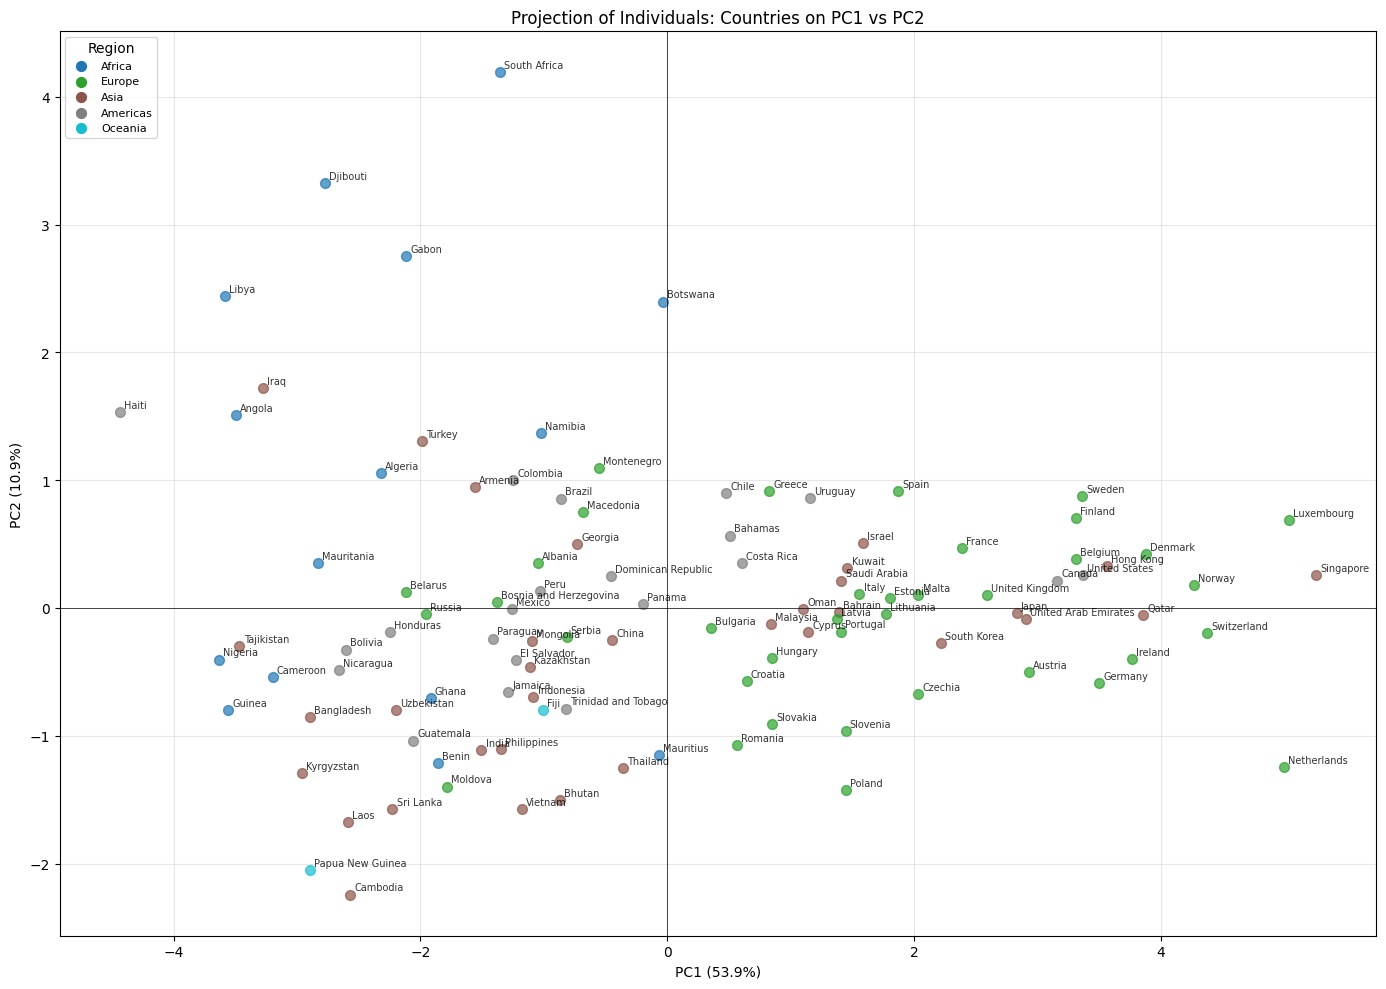

In [60]:
# Concatenate with Country and Region
finalDf = pd.concat([principalDf, df[["Country Name", "Region"]]], axis=1)

# Projection of Individuals (Countries on PC1 vs PC2)
fig, ax = plt.subplots(figsize=(14, 10))

# Get unique regions and assign colors
regions = df["Region"].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(regions)))
region_colors = dict(zip(regions, colors))

# Plot each country
for i, row in finalDf.iterrows():
    region = df.iloc[i]["Region"]
    ax.scatter(row["PC1"], row["PC2"], c=[region_colors[region]], s=50, alpha=0.7)
    ax.annotate(
        df.iloc[i]["Country Name"],
        (row["PC1"], row["PC2"]),
        fontsize=7,
        alpha=0.8,
        xytext=(3, 3),
        textcoords="offset points",
    )

# Add legend for regions
for region, color in region_colors.items():
    ax.scatter([], [], c=[color], label=region, s=50)
ax.legend(title="Region", loc="upper left", fontsize=8)

ax.axhline(y=0, color="k", linestyle="-", linewidth=0.5)
ax.axvline(x=0, color="k", linestyle="-", linewidth=0.5)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Projection of Individuals: Countries on PC1 vs PC2")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Hierarchical Agglomerative Clustering (HAC)

HAC builds a hierarchy of clusters by iteratively merging the most similar pairs. Unlike K-Means, it doesn't require specifying the number of clusters upfront.

**Ward's method** minimizes within-cluster variance at each merge, producing compact, spherical clusters. The **dendrogram** visualizes the merge history - cutting it horizontally at different heights yields different numbers of clusters.


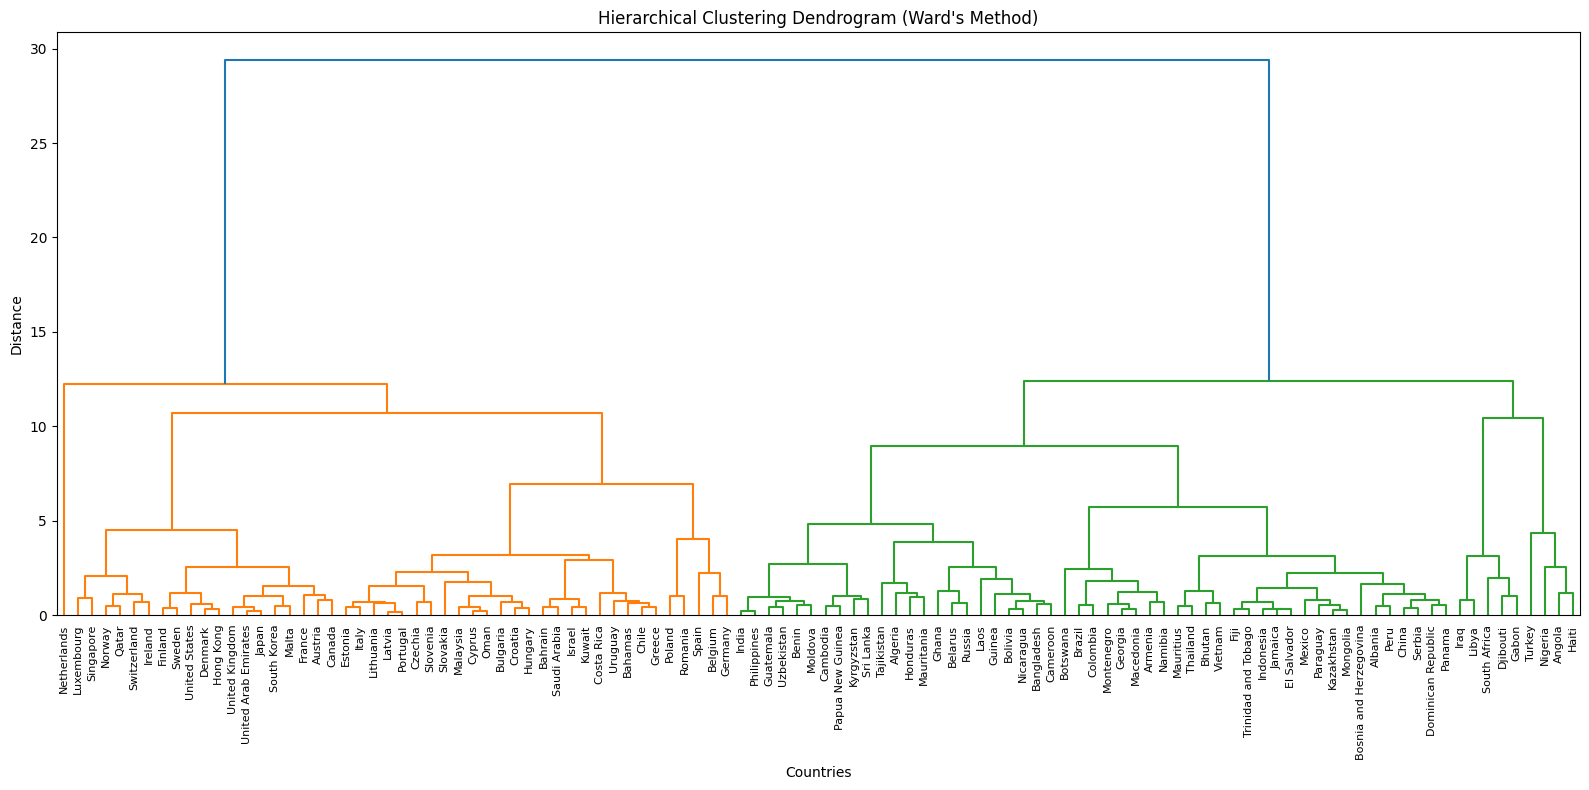

In [61]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Compute linkage matrix using Ward's method (minimizes variance)
linkage_matrix = linkage(principalComponents, method="ward")

# Plot dendrogram
plt.figure(figsize=(16, 8))
dendrogram(
    linkage_matrix,
    labels=df["Country Name"].values,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=25,  # Threshold for coloring clusters
)
plt.title("Hierarchical Clustering Dendrogram (Ward's Method)")
plt.xlabel("Countries")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

### HAC Cluster Assignments

We cut the dendrogram at 6 clusters to match our K-Means analysis. The output shows which countries fall into each cluster, revealing natural groupings based on economic and governance similarity.


In [62]:
# Cut the dendrogram to get cluster assignments
# Using 6 clusters to match k-means analysis
n_clusters_hac = 6
hac_clusters = fcluster(linkage_matrix, n_clusters_hac, criterion="maxclust")

# Add HAC clusters to dataframe
finalDf["HAC_Cluster"] = hac_clusters.astype(str)

# View countries by HAC cluster
print("=== Hierarchical Agglomerative Clustering Results ===\n")
for cluster in range(1, n_clusters_hac + 1):
    print(f"--- HAC Cluster {cluster} ---")
    countries = finalDf[finalDf["HAC_Cluster"] == str(cluster)]["Country Name"].tolist()
    print(", ".join(countries))
    print()

=== Hierarchical Agglomerative Clustering Results ===

--- HAC Cluster 1 ---
United Arab Emirates, Austria, Canada, Switzerland, Denmark, Finland, France, United Kingdom, Hong Kong, Ireland, Japan, South Korea, Luxembourg, Malta, Norway, Qatar, Singapore, Sweden, United States

--- HAC Cluster 2 ---
Belgium, Bulgaria, Bahrain, Bahamas, Chile, Costa Rica, Cyprus, Czechia, Germany, Spain, Estonia, Greece, Croatia, Hungary, Israel, Italy, Kuwait, Lithuania, Latvia, Malaysia, Oman, Poland, Portugal, Romania, Saudi Arabia, Slovakia, Slovenia, Uruguay

--- HAC Cluster 3 ---
Netherlands

--- HAC Cluster 4 ---
Albania, Armenia, Benin, Bangladesh, Bosnia and Herzegovina, Belarus, Bolivia, Brazil, Bhutan, Botswana, China, Cameroon, Colombia, Dominican Republic, Algeria, Fiji, Georgia, Ghana, Guinea, Guatemala, Honduras, Indonesia, India, Jamaica, Kazakhstan, Kyrgyzstan, Cambodia, Laos, Sri Lanka, Moldova, Mexico, Macedonia, Montenegro, Mongolia, Mauritania, Mauritius, Namibia, Nicaragua, Panama,

### HAC Clusters Visualization

Visualizing HAC clusters in PCA space helps validate whether the clustering captures meaningful structure. Well-separated clusters in PC1-PC2 indicate strong groupings.


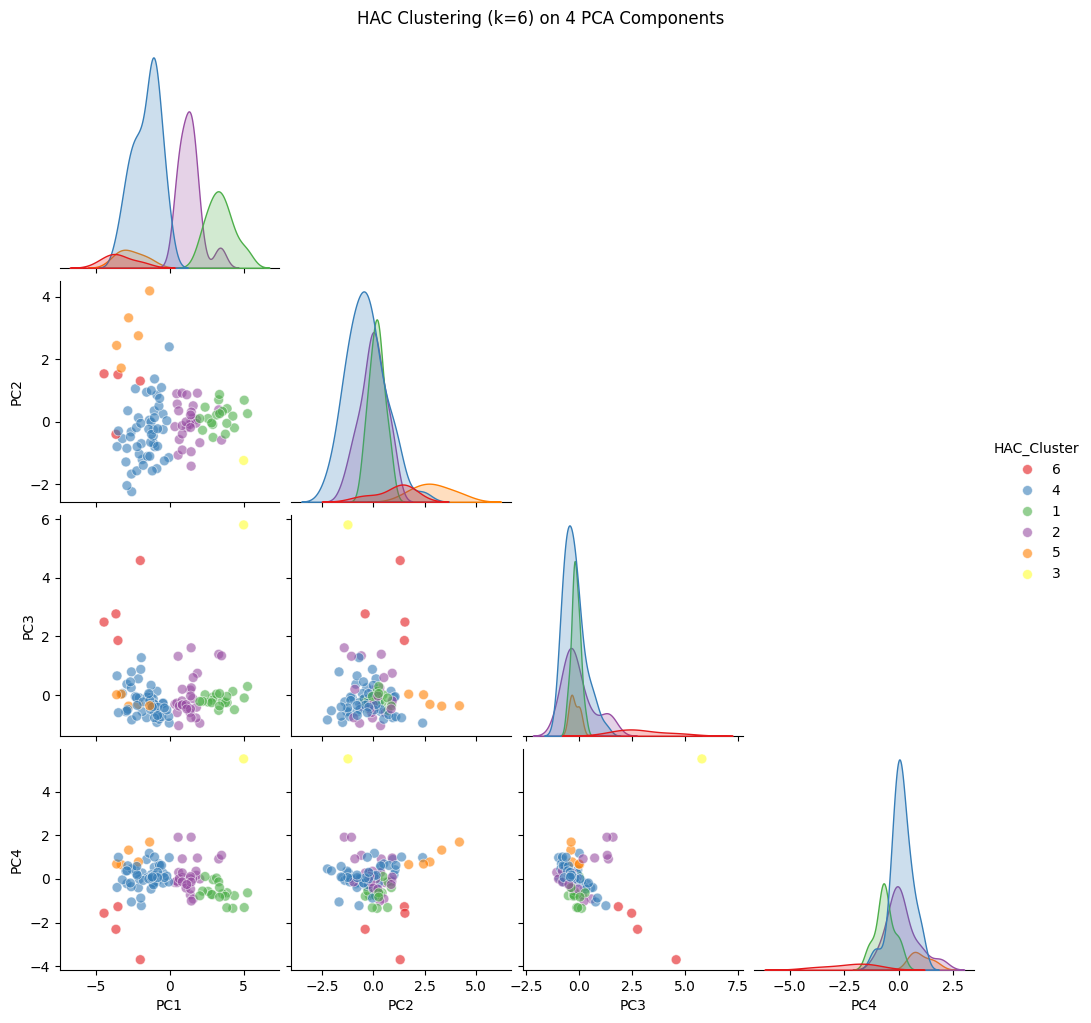

In [63]:
# Visualize HAC clusters on PCA projection
sns.pairplot(
    finalDf,
    hue="HAC_Cluster",
    vars=["PC1", "PC2", "PC3", "PC4"],
    corner=True,
    palette="Set1",
    plot_kws={"alpha": 0.6, "s": 50},
)
plt.suptitle(f"HAC Clustering (k={n_clusters_hac}) on 4 PCA Components", y=1.02)
plt.show()

## K-Means Clustering

K-Means partitions data into k clusters by minimizing within-cluster distances to centroids. Unlike HAC, it requires specifying k upfront, so we use two methods to find the optimal number:

### Elbow Method

Plots **inertia** (sum of squared distances to centroids) vs. number of clusters. The "elbow" point where the curve bends indicates diminishing returns from adding more clusters.


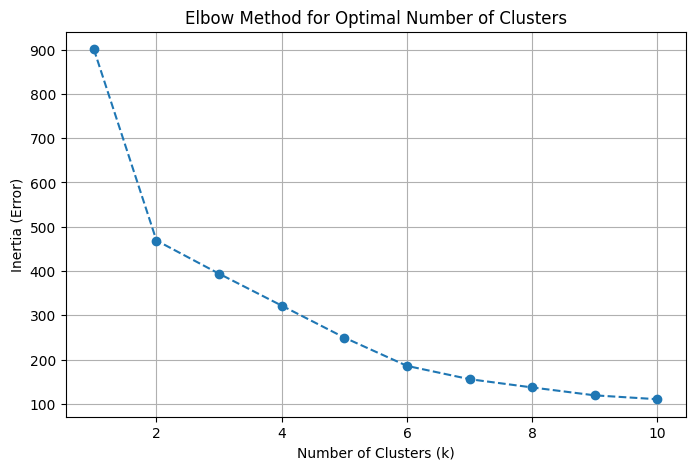

In [64]:
# We calculate 'inertia' (how tightly grouped the clusters are)
# for 1 to 10 different cluster counts
inertia = []
K_range = range(1, 11)

for k in K_range:
    # We use the 4 components you've already calculated
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(principalComponents)
    inertia.append(kmeans.inertia_)

# Plotting the results to find the 'elbow'
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o", linestyle="--")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Error)")
plt.grid(True)
plt.show()

**Elbow interpretation:**

-   **3 clusters** = Broad segmentation: Developed, Emerging, High-Risk markets
-   **6 clusters** = Finer granularity for more targeted analysis

### Silhouette Score

Measures how similar points are to their own cluster vs. neighboring clusters. Scores range from -1 to 1; higher is better. This provides a more objective metric than the elbow method.


2 clusters: Silhouette Score = 0.444
3 clusters: Silhouette Score = 0.324
4 clusters: Silhouette Score = 0.308
5 clusters: Silhouette Score = 0.367
6 clusters: Silhouette Score = 0.372
7 clusters: Silhouette Score = 0.326
8 clusters: Silhouette Score = 0.342
9 clusters: Silhouette Score = 0.348
10 clusters: Silhouette Score = 0.346


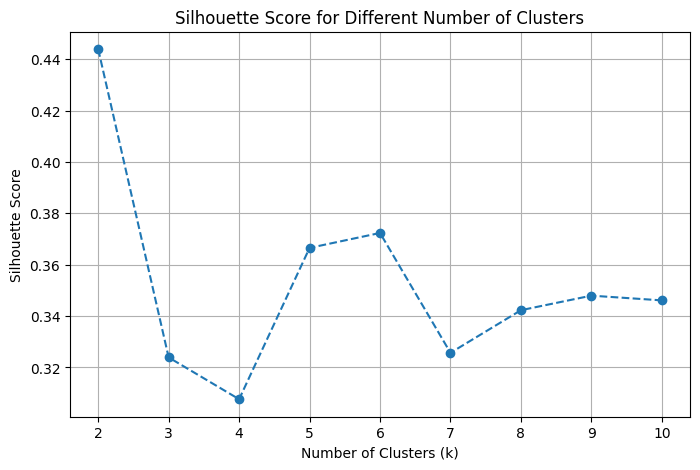


Optimal number of clusters: 2 (score: 0.444)


In [65]:
from sklearn.metrics import silhouette_score

# Calculate silhouette score for k=2 to k=10 (silhouette needs at least 2 clusters)
silhouette_scores = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(principalComponents)
    score = silhouette_score(principalComponents, labels)
    silhouette_scores.append(score)
    print(f"{k} clusters: Silhouette Score = {score:.3f}")
# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker="o", linestyle="--")
plt.title("Silhouette Score for Different Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()
# Best k
best_k = K_range[np.argmax(silhouette_scores)]
print(f"\nOptimal number of clusters: {best_k} (score: {max(silhouette_scores):.3f})")

### Final K-Means Clustering

We apply K-Means with 6 clusters for detailed market segmentation. The cluster assignments will be used for the profile heatmap analysis.


In [66]:
# Apply K-Means with chosen number of clusters (6 for detailed analysis)
n_clusters_kmeans = 6
kmeans_final = KMeans(n_clusters=n_clusters_kmeans, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(principalComponents)

# Add cluster labels to finalDf
finalDf["Cluster"] = kmeans_labels.astype(str)

# View countries by K-Means cluster
print(f"=== K-Means Clustering Results (k={n_clusters_kmeans}) ===\n")
for cluster in range(n_clusters_kmeans):
    print(f"--- Cluster {cluster} ---")
    countries = finalDf[finalDf["Cluster"] == str(cluster)]["Country Name"].tolist()
    print(", ".join(countries))
    print()

=== K-Means Clustering Results (k=6) ===

--- Cluster 0 ---
Albania, Armenia, Brazil, Botswana, Colombia, Djibouti, Algeria, Gabon, Georgia, Iraq, Libya, Macedonia, Montenegro, Namibia, South Africa

--- Cluster 1 ---
United Arab Emirates, Austria, Belgium, Canada, Switzerland, Germany, Denmark, Finland, France, United Kingdom, Hong Kong, Ireland, Japan, Luxembourg, Norway, Qatar, Singapore, Sweden, United States

--- Cluster 2 ---
Bulgaria, Bahrain, Bahamas, Chile, Costa Rica, Cyprus, Czechia, Dominican Republic, Spain, Estonia, Greece, Croatia, Hungary, Israel, Italy, South Korea, Kuwait, Lithuania, Latvia, Malta, Mauritius, Malaysia, Oman, Panama, Poland, Portugal, Romania, Saudi Arabia, Slovakia, Slovenia, Uruguay

--- Cluster 3 ---
Benin, Bangladesh, Bosnia and Herzegovina, Belarus, Bolivia, Bhutan, China, Cameroon, Fiji, Ghana, Guinea, Guatemala, Honduras, Indonesia, India, Jamaica, Kazakhstan, Kyrgyzstan, Cambodia, Laos, Sri Lanka, Moldova, Mexico, Mongolia, Mauritania, Nicaragu

### Cluster Profile Heatmap

This heatmap shows the **average value of each indicator per cluster**. It reveals the "personality" of each group - which clusters have high GDP, low unemployment, strong governance, etc. Use this to identify the most attractive market segments.


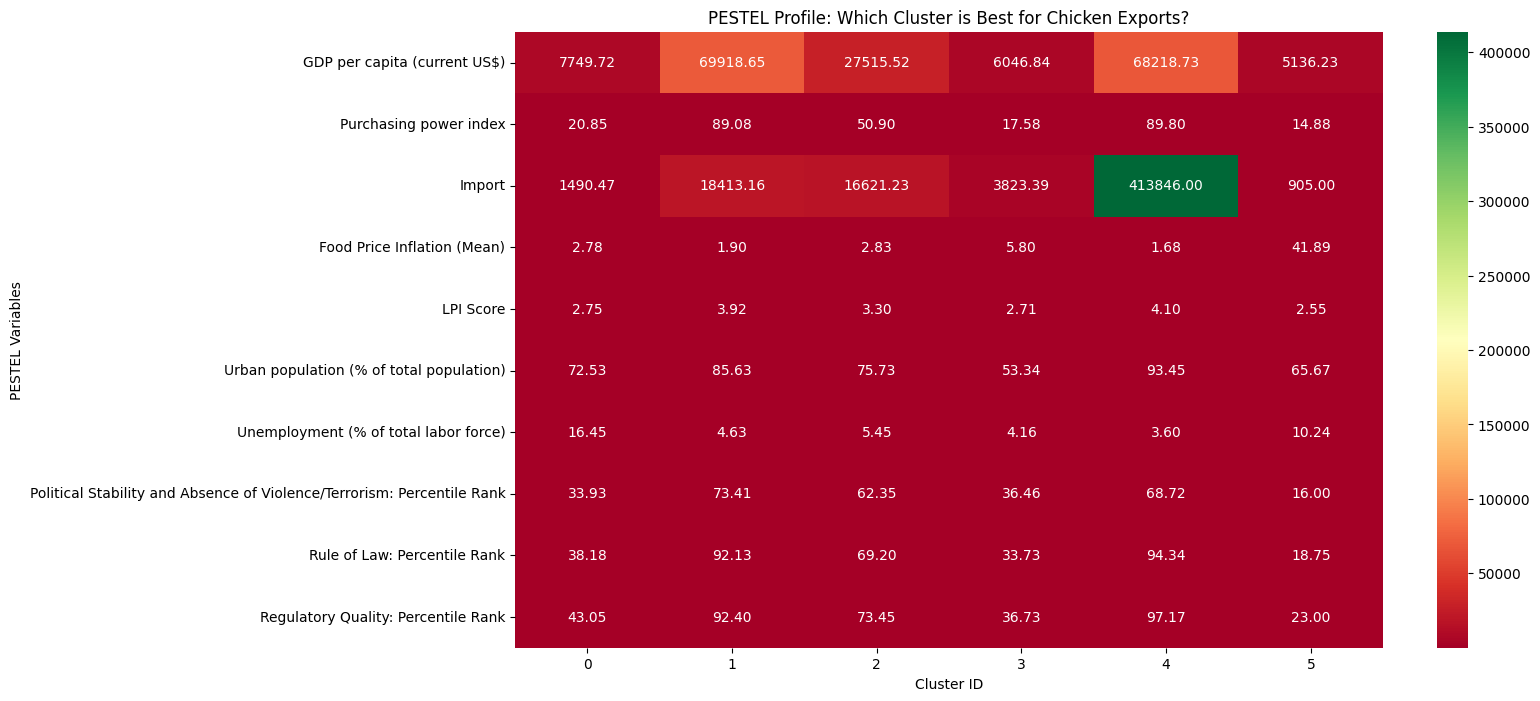

In [67]:
# 1. Add the cluster labels back to your original (unscaled) data
df_profile = df.copy()
df_profile["Cluster"] = finalDf["Cluster"].values

# 2. Calculate the average of each PESTEL variable for each cluster
# This helps us see the "personality" of each group
cluster_means = df_profile.groupby("Cluster")[analysis_features].mean()

# 3. Create a heatmap to compare the clusters
plt.figure(figsize=(14, 8))
sns.heatmap(cluster_means.T, annot=True, cmap="RdYlGn", fmt=".2f")
plt.title("PESTEL Profile: Which Cluster is Best for Chicken Exports?")
plt.ylabel("PESTEL Variables")
plt.xlabel("Cluster ID")
plt.show()